# 🏦 Smart Loan Approval & Risk Assessment System

## Model Training

In this notebook, we train and evaluate multiple machine learning classification algorithms to predict loan approval.

The best-performing model will be selected based on evaluation metrics and saved for deployment in the FastAPI backend and Streamlit frontend.

## Step 1: Import Libraries

Import all required libraries for model training and evaluation.

In [29]:
# Data Manipulation
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Step 2: Load Processed Dataset

In [30]:
df = pd.read_csv("../data/processed/processed_loan.csv")

print("Processed dataset loaded successfully.")

df.head()

Processed dataset loaded successfully.


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


## Step 3: Features and Target

Separate the dataset into input features (`X`) and target labels (`y`).

In [31]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

print("Features Shape :", X.shape)

print("Target Shape   :", y.shape)

Features Shape : (4269, 11)
Target Shape   : (4269,)


## Step 4: Train-Test Split

Split the dataset into training and testing sets while preserving the class distribution.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Step 5: Define Machine Learning Models

Instead of training each model separately, we define them in a dictionary.

This approach keeps the code clean, scalable, and easier to maintain.

In [33]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42)

}

## Step 6: Train and Evaluate Models

Each model is trained using the training dataset and evaluated on the testing dataset.

The following metrics are recorded:

- Accuracy
- Precision
- Recall
- F1-Score

In [34]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-Score": f1

    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.983607,0.990476,0.965944,0.978056
3,Gradient Boosting,0.982436,0.987342,0.965944,0.976526
1,Decision Tree,0.971897,0.974603,0.950464,0.962382
0,Logistic Regression,0.807963,0.824490,0.625387,0.711268


## Step 7: Select the Best Model

Based on the evaluation metrics, the Random Forest Classifier achieved the highest overall performance.

It will be selected as the final model for deployment.

In [35]:
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

print("✅ Best model trained successfully.")

✅ Best model trained successfully.


In [36]:
# Predictions
predictions = best_model.predict(X_test)

## Step 10: Confusion Matrix

A confusion matrix summarizes the prediction performance by showing:

- True Positives
- True Negatives
- False Positives
- False Negatives

It helps identify the types of prediction errors made by the model.

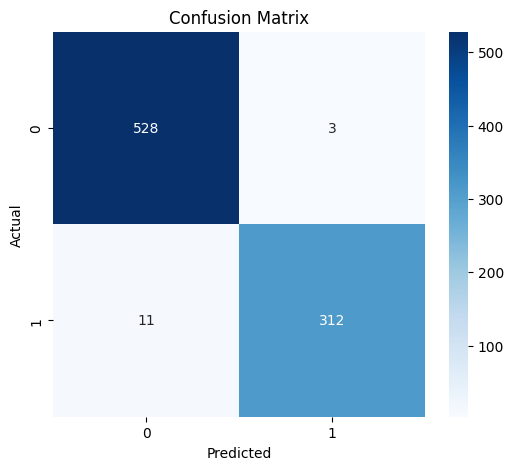

In [37]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "../screenshots/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# Print Classification Report
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



## Step 12: Save the Trained Model

The trained Random Forest model is saved using Joblib.

This saved model will later be loaded by the FastAPI backend to serve predictions through a REST API.

In [39]:
joblib.dump(
    best_model,
    "../models/loan_approval_model.pkl"
)

print("✅ Model saved successfully.")

✅ Model saved successfully.


In [41]:
# verify model
loaded_model = joblib.load(
    "../models/loan_approval_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


# Model Training Summary

The following models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Among these, the **Random Forest Classifier** achieved the best performance and was selected for deployment.

The trained model was saved successfully for use in the FastAPI backend and Streamlit frontend.